In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import logging
import warnings
warnings.filterwarnings('ignore')

# Configuración de rutas para enviar el logger a la carpeta central
BASE_DIR = Path.cwd().parent
CARPETA_LOGS = BASE_DIR / 'reportes'
CARPETA_LOGS.mkdir(exist_ok=True)
ruta_log = CARPETA_LOGS / 'mother_pipeline.log'

# Configuración del Logger (filemode='a' para agregar debajo del registro anterior)
logging.basicConfig(
    filename=str(ruta_log),
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='a'
)
logger = logging.getLogger(__name__)

logger.info("Inicio del notebook 3_Modelado_Evaluacion")



In [2]:
# Variables globales (Pueden ser sobrescritas por Papermill)
RUTA_DATOS = '../data/processed/datos_modelo.csv'
RUTA_MODELO_SALIDA = '../models/motor_mother_produccion.pkl'
SEMILLA = 42

In [3]:
# ==========================================
# Carga de Datos (Resolución Inteligente)
# ==========================================
logger.info("Iniciando ingesta de datos...")

ruta_csv = Path(RUTA_DATOS)

# Inteligencia de rutas: Si VSCode no la encuentra con '../', busca desde la raíz
if not ruta_csv.exists():
    ruta_alternativa = Path.cwd() / 'data' / 'processed' / 'datos_modelo.csv'
    if ruta_alternativa.exists():
        ruta_csv = ruta_alternativa

try:
    df_modelo = pd.read_csv(ruta_csv)
    logger.info(f"✅ Datos cargados exitosamente: {df_modelo.shape}")
    print(f"✅ Datos cargados correctamente. Filas y columnas: {df_modelo.shape}")
except FileNotFoundError as e:
    logger.error(f"❌ Error CRÍTICO: No se encontró el dataset en: {ruta_csv}")
    print(f"⛔ ARCHIVO NO ENCONTRADO. Revisa que el CSV exista en la ruta.")
    raise e  # Frenamos la ejecución acá mismo para que no genere NameError abajo

✅ Datos cargados correctamente. Filas y columnas: (60910, 28)


Bloque de Preparación: Filtro Anti-Leakage y Binarización
Aplicamos la "lista blanca" estricta de columnas y transformamos el problema a binario (Mortal vs. No Mortal).

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

logger.info("Iniciando selección estricta y binarización.")

# 1. Selección Estricta (Evitar Data Leakage)
df_modelo = df_modelo.rename(columns={'anio_siniestro_x': 'anio_siniestro', 'modo_desplazamiento_victima_x': 'modo_desplazamiento_victima'})

columnas_predictivas = [
    'rol_victima', 'modo_desplazamiento_victima', 'sexo_victima', 'edad_victima', 
    'franja_horaria', 'tipo_de_via_siniestro', 'comuna_siniestro', 
    'contraparte_siniestro', 'participantes_siniestro', 'anio_siniestro', 
    'mes_siniestro', 'dia_siniestro'
]

X = df_modelo[columnas_predictivas].copy()

# 2. Binarización (1 = MORTAL, 0 = TODO LO DEMÁS)
y_binaria = (df_modelo['gravedad_victima'] == 'MORTAL').astype(int)

# 3. Codificación Label Encoding
cols_categoricas = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in cols_categoricas:
    le_temp = LabelEncoder()
    X[col] = X[col].fillna('MISSING')
    X[col] = le_temp.fit_transform(X[col])
    label_encoders[col] = le_temp

# 4. División de datos (Separamos el Test Set para el final)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binaria, test_size=0.2, stratify=y_binaria, random_state=SEMILLA
)
logger.info(f"Set de Entrenamiento: {X_train.shape[0]} | Set de Prueba: {X_test.shape[0]}")

In [5]:
from scipy.stats import chisquare
import pandas as pd

logger.info("Realizando Prueba Chi-Cuadrado de representatividad (Train vs Test)...")

# Calculamos las proporciones
dist_original = y_binaria.value_counts(normalize=True).sort_index()
dist_train = y_train.value_counts(normalize=True).sort_index()
dist_test = y_test.value_counts(normalize=True).sort_index()

# Mostramos la tabla como pide el PDF
df_dist = pd.DataFrame({
    'Original (%)': dist_original * 100,
    'Train (%)': dist_train * 100,
    'Test (%)': dist_test * 100
}).round(2)
print("=== DISTRIBUCIÓN DE CLASES ===")
display(df_dist)

# Test Chi-Cuadrado (Comparamos frecuencias observadas en Test vs esperadas según Train)
frec_esperadas = dist_train * len(y_test)
frec_observadas = y_test.value_counts().sort_index()

chi2_stat, p_val = chisquare(f_obs=frec_observadas, f_exp=frec_esperadas)
print(f"\nPrueba Chi-Cuadrado: p-value = {p_val:.4f}")
if p_val > 0.05:
    print("✅ APROBADO: No hay diferencia significativa. El split es perfectamente representativo.")
else:
    print("❌ ADVERTENCIA: El split alteró la distribución original.")

=== DISTRIBUCIÓN DE CLASES ===


,Original (%),Train (%),Test (%)
gravedad_victima,,,
0,99.0,99.0,99.0
1,1.0,1.0,1.0



Prueba Chi-Cuadrado: p-value = 1.0000
✅ APROBADO: No hay diferencia significativa. El split es perfectamente representativo.


Bloque de Balanceo: Undersampling
Aplicamos el ratio que descubriste en tus pruebas anteriores para equilibrar el entrenamiento sin perder el foco en la clase mortal.

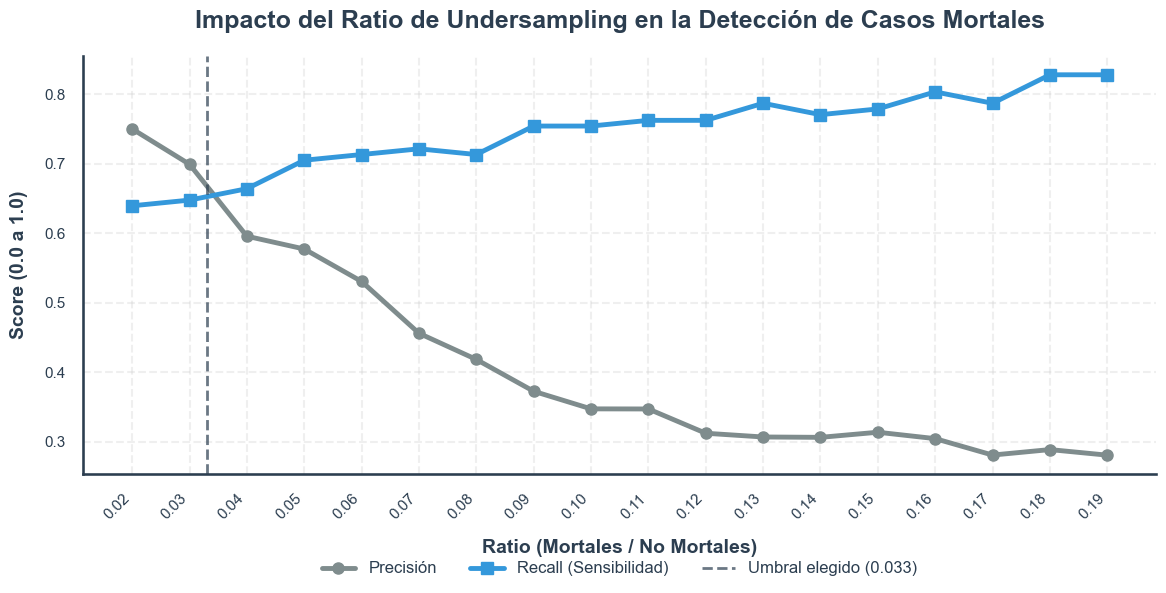


=== TABLA DE MÉTRICAS POR RATIO ===
 Ratio  Precision   Recall
  0.02   0.750000 0.639344
  0.03   0.699115 0.647541
  0.04   0.595588 0.663934
  0.05   0.577181 0.704918
  0.06   0.530488 0.713115
  0.07   0.455959 0.721311
  0.08   0.418269 0.713115
  0.09   0.372470 0.754098
  0.10   0.347170 0.754098
  0.11   0.347015 0.762295
  0.12   0.312081 0.762295
  0.13   0.306709 0.786885
  0.14   0.306189 0.770492
  0.15   0.313531 0.778689
  0.16   0.304348 0.803279
  0.17   0.280702 0.786885
  0.18   0.288571 0.827869
  0.19   0.280556 0.827869


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Sumamos seaborn para la estética ejecutiva
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score

logger.info("Iniciando barrido iterativo de ratios de Undersampling...")

# Definimos los ratios a probar: de 0.02 a 0.5 en saltos de 0.01
ratios = np.arange(0.02, 0.2, 0.01)
resultados = []

for ratio in ratios:
    # 1. Aplicar Undersampling con el ratio actual
    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=SEMILLA)
    X_train_res_temp, y_train_res_temp = rus.fit_resample(X_train, y_train)
    
    # 2. Entrenar un modelo temporal rápido
    modelo_temp = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=100,
        max_depth=5,
        random_state=SEMILLA,
        n_jobs=-1
    )
    modelo_temp.fit(X_train_res_temp, y_train_res_temp)
    
    # 3. Predecir sobre el Test Set (usamos umbral fijo de 0.5 para comparar ratios de forma justa)
    y_pred_temp = modelo_temp.predict(X_test)
    
    # 4. Calcular métricas exclusivamente para la clase MORTAL (1)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)
    rec = recall_score(y_test, y_pred_temp)
    
    resultados.append({'Ratio': ratio, 'Precision': prec, 'Recall': rec})

# Convertimos a DataFrame para visualizar
df_resultados = pd.DataFrame(resultados)

# ==========================================
# GRAFICAMOS EL IMPACTO (ESTILO M.O.T.H.E.R)
# ==========================================
plt.style.use('default')
sns.set_theme(style="white", context="talk")

# Paleta de Colores MLOps
COLOR_RECALL = '#3498DB'      # Azul/Turquesa institucional (Nuestra métrica Foco)
COLOR_PRECISION = '#7F8C8D'   # Gris Basal (Métrica de Contexto)
COLOR_TEXTO = '#2C3E50'       # Azul marino para textos

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='white')
ax.set_facecolor('white')

ax.plot(df_resultados['Ratio'], df_resultados['Precision'], label='Precisión', 
        marker='o', linewidth=3.5, markersize=8, color=COLOR_PRECISION)
ax.plot(df_resultados['Ratio'], df_resultados['Recall'], label='Recall (Sensibilidad)', 
        marker='s', linewidth=3.5, markersize=8, color=COLOR_RECALL)

ax.axvline(x=0.033, color=COLOR_TEXTO, linestyle='--', linewidth=2, alpha=0.7, label='Umbral elegido (0.033)')

# Estética ejecutiva
ax.set_title('Impacto del Ratio de Undersampling en la Detección de Casos Mortales', 
             fontsize=18, fontweight='bold', color=COLOR_TEXTO, pad=20)
ax.set_xlabel('Ratio (Mortales / No Mortales)', fontsize=14, fontweight='bold', color=COLOR_TEXTO, labelpad=12)
ax.set_ylabel('Score (0.0 a 1.0)', fontsize=14, fontweight='bold', color=COLOR_TEXTO, labelpad=12)

# Ajuste de ticks en el eje X para que no se superpongan
ax.set_xticks(ratios)
ax.set_xticklabels([f'{r:.2f}' for r in ratios], rotation=45, ha='right')

# Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLOR_TEXTO)
ax.spines['bottom'].set_color(COLOR_TEXTO)
ax.tick_params(colors=COLOR_TEXTO, labelsize=11)
ax.grid(True, linestyle='--', alpha=0.3)

# Leyenda horizontal limpia en la parte inferior
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=3, 
          frameon=False, fontsize=12, labelcolor=COLOR_TEXTO)

plt.tight_layout()
plt.show()

# Imprimimos la tabla de soporte
print("\n=== TABLA DE MÉTRICAS POR RATIO ===")
print(df_resultados.to_string(index=False))

In [6]:
from imblearn.under_sampling import RandomUnderSampler

logger.info("Aplicando Undersampling estratégico...")

# Ratio 0.1 
rus = RandomUnderSampler(sampling_strategy=0.033, random_state=SEMILLA)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

logger.info(f"Datos de entrenamiento balanceados: {X_train_res.shape[0]} casos.")
logger.info(f"Distribución: {sum(y_train_res==0)} No Mortales, {sum(y_train_res==1)} Mortales.")

2026-06-14 14:28:00,328 - INFO - Aplicando Undersampling estratégico...
2026-06-14 14:28:00,342 - INFO - Datos de entrenamiento balanceados: 15275 casos.
2026-06-14 14:28:00,344 - INFO - Distribución: 14787 No Mortales, 488 Mortales.


In [7]:
# 1. Obtenemos la relación ANTES del undersampling
total_antes = len(y_train)
mortales_antes = sum(y_train == 1)
no_mortales_antes = sum(y_train == 0)
proporcion_original = (mortales_antes / no_mortales_antes) * 100

logger.info(f"--- ANTES DEL UNDERSAMPLING ---")
logger.info(f"Total casos: {total_antes}")
logger.info(f"Distribución original: {no_mortales_antes} No Mortales, {mortales_antes} Mortales.")
logger.info(f"Relación original (Minoritaria/Mayoritaria): {proporcion_original:.2f}%")

# 2. Aplicamos el Undersampling
rus = RandomUnderSampler(sampling_strategy=0.033, random_state=SEMILLA)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# 3. Obtenemos la relación DESPUÉS del undersampling
total_despues = len(y_train_res)
mortales_despues = sum(y_train_res == 1)
no_mortales_despues = sum(y_train_res == 0)
proporcion_nueva = (mortales_despues / no_mortales_despues) * 100

logger.info(f"--- DESPUÉS DEL UNDERSAMPLING (Umbral 0.033) ---")
logger.info(f"Datos de entrenamiento balanceados: {total_despues} casos.")
logger.info(f"Distribución: {no_mortales_despues} No Mortales, {mortales_despues} Mortales.")
logger.info(f"Nueva relación: {proporcion_nueva:.2f}%")

2026-06-14 14:28:03,424 - INFO - --- ANTES DEL UNDERSAMPLING ---
2026-06-14 14:28:03,426 - INFO - Total casos: 48728
2026-06-14 14:28:03,426 - INFO - Distribución original: 48240 No Mortales, 488 Mortales.
2026-06-14 14:28:03,426 - INFO - Relación original (Minoritaria/Mayoritaria): 1.01%
2026-06-14 14:28:03,442 - INFO - --- DESPUÉS DEL UNDERSAMPLING (Umbral 0.033) ---
2026-06-14 14:28:03,443 - INFO - Datos de entrenamiento balanceados: 15275 casos.
2026-06-14 14:28:03,444 - INFO - Distribución: 14787 No Mortales, 488 Mortales.
2026-06-14 14:28:03,444 - INFO - Nueva relación: 3.30%


Bloque de Evaluación Base: Modelos con Cross-Validation
Comparamos un Random Forest y un XGBoost "de fábrica" usando validación cruzada para ver cómo se comportan sobre los datos balanceados antes de tocarlos.

In [10]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 38.4 MB/s  0:00:00



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import cross_validate
import pandas as pd

logger.info("Evaluando líneas base de 3 modelos con Cross-Validation...")

# 1. Definición de los 3 Modelos (Configuración Base)
modelos_a_probar = {
    "Random Forest": RandomForestClassifier(random_state=SEMILLA, n_jobs=-1),
    
    "XGBoost": xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=SEMILLA,
        n_jobs=-1,
        eval_metric='logloss' # Para evitar warnings de XGBoost
    ),
    
    "LightGBM": lgb.LGBMClassifier(
        objective='binary',
        random_state=SEMILLA,
        n_jobs=-1,
        verbose=-1 # Para que no inunde la consola con mensajes
    )
}

# 2. Función de Cross Validation Avanzada (Métricas + Desvío Estándar)
def evaluar_cv_tabla_completa(modelos_dict, X, y):
    resultados = []
    
    for nombre, modelo in modelos_dict.items():
        logger.info(f"Procesando {nombre}...")
        
        # Validación Cruzada (5 cortes)
        cv_results = cross_validate(
            modelo, X, y, cv=5, 
            scoring=['recall', 'precision'], 
            n_jobs=-1
        )
        
        # Extracción de promedios (Mean) y desvíos (Std)
        recall_mean = cv_results['test_recall'].mean()
        recall_std = cv_results['test_recall'].std()
        
        precision_mean = cv_results['test_precision'].mean()
        precision_std = cv_results['test_precision'].std()
        
        fit_time_mean = cv_results['fit_time'].mean()
        
        resultados.append({
            'Modelo': nombre,
            'Recall (Mean)': recall_mean,
            'Recall (Std)': recall_std,
            'Precisión (Mean)': precision_mean,
            'Precisión (Std)': precision_std,
            'Tiempo Entrenam. (s)': fit_time_mean
        })
        
    # 3. Formateo de la tabla de salida
    df_metricas = pd.DataFrame(resultados)
    df_metricas = df_metricas.sort_values(by='Recall (Mean)', ascending=False).reset_index(drop=True)
    
    # Redondeamos los números para que sea legible
    cols_numericas = ['Recall (Mean)', 'Recall (Std)', 'Precisión (Mean)', 'Precisión (Std)']
    df_metricas[cols_numericas] = df_metricas[cols_numericas].round(4)
    df_metricas['Tiempo Entrenam. (s)'] = df_metricas['Tiempo Entrenam. (s)'].round(2)
    
    return df_metricas

# 4. Ejecución
tabla_comparativa = evaluar_cv_tabla_completa(modelos_a_probar, X_train_res, y_train_res)

print("\n=== COMPARATIVA DE MODELOS BASE (CROSS-VALIDATION 5-FOLDS) ===")
# Muestra la tabla de forma visualmente atractiva en Jupyter
display(tabla_comparativa)

2026-06-14 14:28:10,965 - INFO - Evaluando líneas base de 3 modelos con Cross-Validation...
2026-06-14 14:28:10,967 - INFO - Procesando Random Forest...
2026-06-14 14:28:14,282 - INFO - Procesando XGBoost...
2026-06-14 14:28:16,066 - INFO - Procesando LightGBM...



=== COMPARATIVA DE MODELOS BASE (CROSS-VALIDATION 5-FOLDS) ===


,Modelo,Recall (Mean),Recall (Std),Precisión (Mean),Precisión (Std),Tiempo Entrenam. (s)
0,XGBoost,0.6700,0.0336,0.8679,0.0340,0.11
1,LightGBM,0.6618,0.0421,0.8982,0.0352,1.11
2,Random Forest,0.6167,0.0451,0.9550,0.0135,0.38


Bloque de Sintonía Fina: El XGBoost Definitivo
Elegimos XGBoost (que suele ganar en estos escenarios) y buscamos sus mejores parámetros priorizando el Recall.

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import time
import numpy as np # Necesitamos numpy para usar np.arange y distribuciones
from scipy.stats import randint, uniform # Herramientas pro para RandomizedSearchCV

logger.info("Iniciando búsqueda de hiperparámetros (Tuning) para RF, XGBoost y LightGBM...")

# ==========================================
# 1. Tuning de Random Forest
# ==========================================
logger.info("Optimizando Random Forest (Búsqueda Exhaustiva)...")
param_grid_rf_ampliado = {
    'n_estimators': [100, 200, 300, 500], # Se prueba hasta 500 árboles
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None], # Importante para diversificar árboles
    'class_weight': ['balanced', 'balanced_subsample'] # Quitamos None, sabemos que están desbalanceados
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEMILLA, n_jobs=-1),
    param_distributions=param_grid_rf_ampliado,
    n_iter=50, # Aumentado a 50 pruebas aleatorias
    scoring='recall', 
    cv=5,
    random_state=SEMILLA,
    n_jobs=-1
)

start_time_rf = time.time()
rf_search.fit(X_train_res, y_train_res)
rf_time = time.time() - start_time_rf
mejor_rf = rf_search.best_estimator_

# ==========================================
# 2. Tuning de XGBoost
# ==========================================
logger.info("Optimizando XGBoost (Búsqueda Exhaustiva)...")
param_grid_xgb_ampliado = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 0.9, 1.0], # Muestreo de filas
    'colsample_bytree': [0.6, 0.8, 0.9, 1.0], # Muestreo de columnas
    'scale_pos_weight': [1, 2, 3, 5], # Forzamos aún más la captura de positivos
    'gamma': [0, 0.1, 0.5, 1], # Penalización por crear nuevas ramas
    'min_child_weight': [1, 3, 5, 7] # Requiere más evidencia para particionar
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic', random_state=SEMILLA, eval_metric='logloss'),
    param_distributions=param_grid_xgb_ampliado,
    n_iter=50, # Aumentado a 50 pruebas
    scoring='recall',
    cv=5,
    random_state=SEMILLA,
    n_jobs=-1
)

start_time_xgb = time.time()
xgb_search.fit(X_train_res, y_train_res)
xgb_time = time.time() - start_time_xgb
mejor_xgb = xgb_search.best_estimator_

# ==========================================
# 3. Tuning de LightGBM (NUEVO)
# ==========================================
logger.info("Optimizando LightGBM (Búsqueda Exhaustiva)...")
param_grid_lgb_ampliado = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 3, 5],
    'num_leaves': [31, 50, 100], # Parámetro crucial en LightGBM
    'min_child_samples': [10, 20, 30] # Equivalente a min_samples_leaf
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(objective='binary', random_state=SEMILLA, n_jobs=-1, verbose=-1),
    param_distributions=param_grid_lgb_ampliado,
    n_iter=50, # Aumentado a 50 pruebas
    scoring='recall',
    cv=5,
    random_state=SEMILLA,
    n_jobs=-1
)

start_time_lgb = time.time()
lgb_search.fit(X_train_res, y_train_res)
lgb_time = time.time() - start_time_lgb
mejor_lgb = lgb_search.best_estimator_

# ==========================================
# 4. El Veredicto Final a Tres Bandas
# ==========================================
print("\n" + "="*50)
print("VEREDICTO FINAL DE SINTONÍA FINA (MAXIMIZANDO RECALL)")
print("="*50)

print(f"\n--- RANDOM FOREST OPTIMIZADO ---")
print(f"Mejor Recall CV: {rf_search.best_score_:.4f}")
print(f"Tiempo: {rf_time:.2f} s")

print(f"\n--- XGBOOST OPTIMIZADO ---")
print(f"Mejor Recall CV: {xgb_search.best_score_:.4f}")
print(f"Tiempo: {xgb_time:.2f} s")

print(f"\n--- LIGHTGBM OPTIMIZADO ---")
print(f"Mejor Recall CV: {lgb_search.best_score_:.4f}")
print(f"Tiempo: {lgb_time:.2f} s")

# Lógica para elegir al ganador entre los tres
resultados_finales = {
    "Random Forest": (rf_search.best_score_, mejor_rf),
    "XGBoost": (xgb_search.best_score_, mejor_xgb),
    "LightGBM": (lgb_search.best_score_, mejor_lgb)
}

# Ordenamos para obtener el que tenga el puntaje más alto
nombre_ganador = max(resultados_finales, key=lambda k: resultados_finales[k][0])
modelo_definitivo = resultados_finales[nombre_ganador][1]

print(f"\nEl mejor modelo base es: {nombre_ganador} ")
logger.info(f"Modelo final seleccionado: {nombre_ganador}")

2026-06-14 14:28:22,235 - INFO - Iniciando búsqueda de hiperparámetros (Tuning) para RF, XGBoost y LightGBM...
2026-06-14 14:28:22,237 - INFO - Optimizando Random Forest (Búsqueda Exhaustiva)...
2026-06-14 14:29:21,615 - INFO - Optimizando XGBoost (Búsqueda Exhaustiva)...
2026-06-14 14:29:39,273 - INFO - Optimizando LightGBM (Búsqueda Exhaustiva)...
2026-06-14 14:30:51,153 - INFO - Modelo final seleccionado: Random Forest



VEREDICTO FINAL DE SINTONÍA FINA (MAXIMIZANDO RECALL)

--- RANDOM FOREST OPTIMIZADO ---
Mejor Recall CV: 0.9652
Tiempo: 59.38 s

--- XGBOOST OPTIMIZADO ---
Mejor Recall CV: 0.7642
Tiempo: 17.66 s

--- LIGHTGBM OPTIMIZADO ---
Mejor Recall CV: 0.7704
Tiempo: 71.88 s

El mejor modelo base es: Random Forest 


Bloque Final: Optimización de Umbral y Exportación
Usamos el modelo mejorado para predecir sobre el Test Set, elegimos el umbral táctico y empaquetamos.

2026-06-14 14:30:55,988 - INFO - Generando Panel de Control de Umbrales para la decisión final...


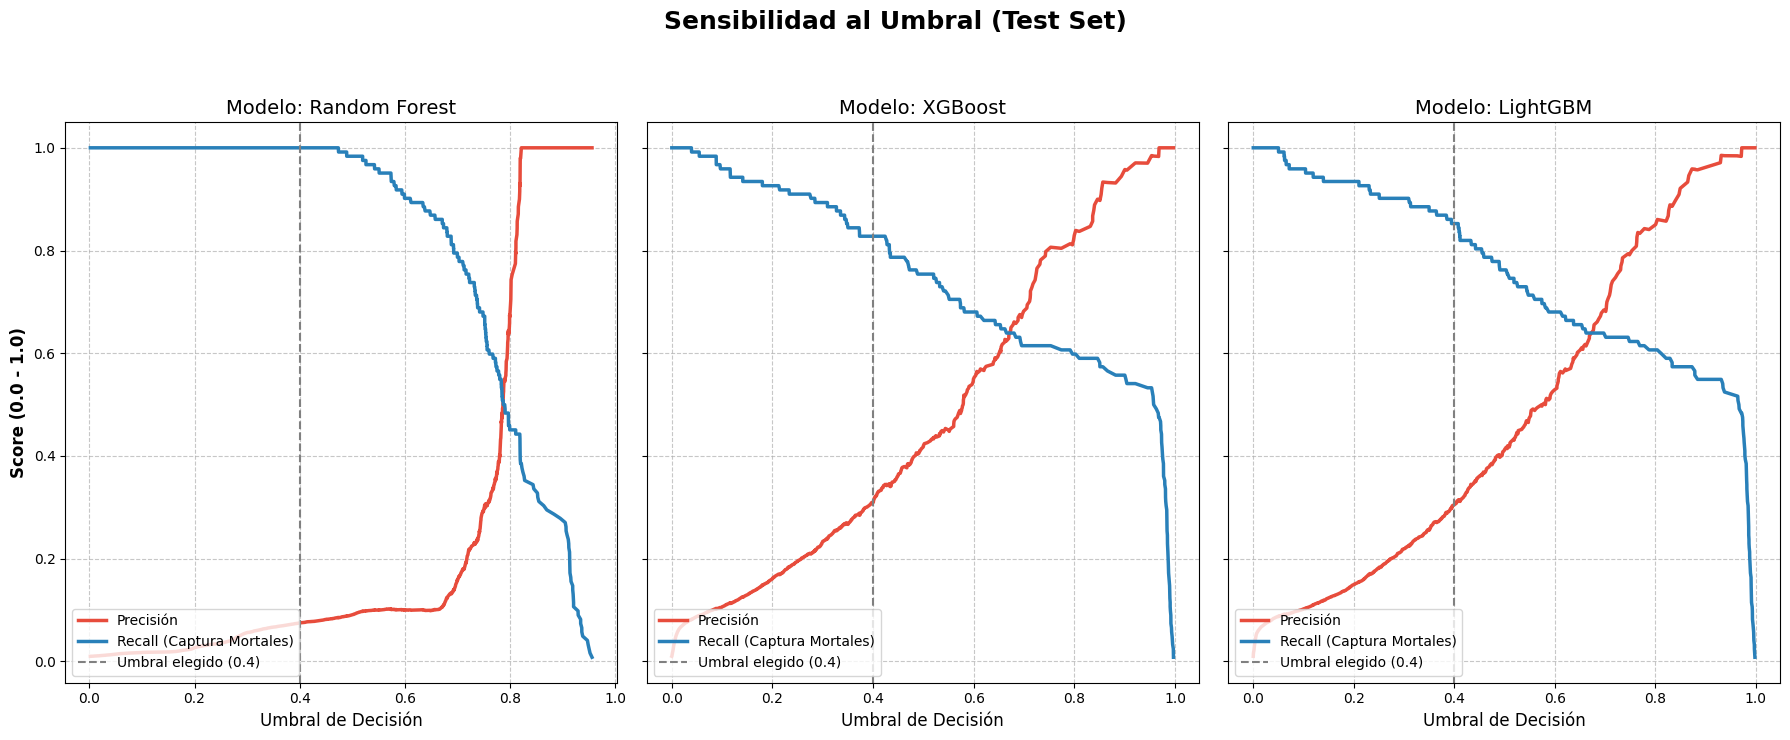

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

logger.info("Generando Panel de Control de Umbrales para la decisión final...")

# 1. Agrupamos los modelos que vamos a someter a la prueba de fuego
# NOTA: Reemplaza las variables por los nombres exactos de tus modelos entrenados
modelos_finales = {
    "Random Forest": mejor_rf, # O rf_base si estás usando los sin tunear
    "XGBoost": mejor_xgb,      # O xgb_base
    "LightGBM": mejor_lgb      # O lgb_base (si lo optimizaste)
}

# 2. Preparamos el lienzo (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle('Sensibilidad al Umbral (Test Set)', fontsize=18, fontweight='bold', y=1.05)

# 3. Iteramos y graficamos cada modelo
for ax, (nombre, modelo) in zip(axes, modelos_finales.items()):
    
    # A. Predecimos probabilidades sobre los datos invisibles (X_test)
    probs = modelo.predict_proba(X_test)[:, 1]
    
    # B. Calculamos las curvas
    precision, recall, umbrales = precision_recall_curve(y_test, probs)
    
    # C. Dibujamos
    ax.plot(umbrales, precision[:-1], label="Precisión", linewidth=2.5, color='#e74c3c')
    ax.plot(umbrales, recall[:-1], label="Recall (Captura Mortales)", linewidth=2.5, color='#2980b9')
    
    # D. Marcador visual del umbral estándar

    ax.axvline(x=0.4, color='grey', linestyle='--', label='Umbral elegido (0.4)')

    # Configuraciones estéticas
    ax.set_title(f"Modelo: {nombre}", fontsize=14)
    ax.set_xlabel("Umbral de Decisión", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="lower left")

# Solo le ponemos la etiqueta 'Y' al primer gráfico para que quede limpio
axes[0].set_ylabel("Score (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Modelo LightGBM

2026-06-14 14:33:04,256 - INFO - Generando Panel de Umbral enfocado en LightGBM...


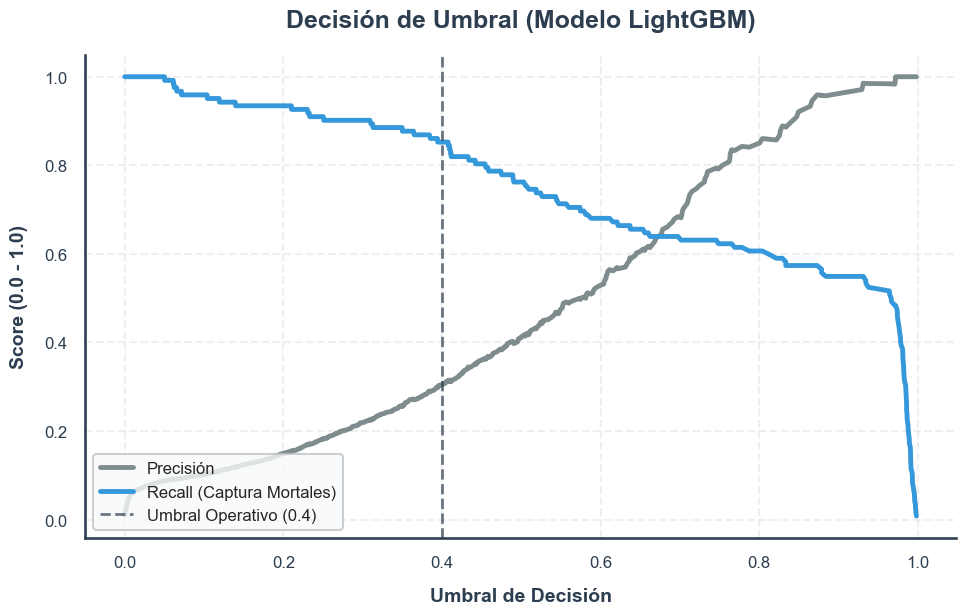

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import seaborn as sns

def graficar_umbral_lightgbm(modelo_lgb, X_test, y_test, umbral_elegido=0.43):
    """
    Genera el gráfico de Sensibilidad al Umbral enfocado únicamente en el modelo 
    ganador (LightGBM), utilizando el diseño institucional M.O.T.H.E.R.
    """
    logger.info("Generando Panel de Umbral enfocado en LightGBM...")
    
    # Configuración de Estilo MOTHER
    plt.style.use('default')
    sns.set_theme(style="white", context="talk")
    
    # Paleta Unificada
    COLOR_RECALL = '#3498DB'      # Azul/Turquesa institucional (Foco: Nuestra métrica estrella)
    COLOR_PRECISION = '#7F8C8D'   # Gris Basal (Contexto: Métrica secundaria)
    COLOR_TEXTO = '#2C3E50'       # Azul marino para los ejes

    # Preparamos el lienzo (1 sola figura central)
    fig, ax = plt.subplots(figsize=(10, 6.5), facecolor='white')
    ax.set_facecolor('white')

    # A. Predecimos probabilidades sobre los datos invisibles (X_test)
    probs = modelo_lgb.predict_proba(X_test)[:, 1]
    
    # B. Calculamos las curvas
    precision, recall, umbrales = precision_recall_curve(y_test, probs)
    
    # C. Dibujamos las curvas con mayor grosor para proyectar en pantalla
    ax.plot(umbrales, precision[:-1], label="Precisión", linewidth=3.5, color=COLOR_PRECISION)
    ax.plot(umbrales, recall[:-1], label="Recall (Captura Mortales)", linewidth=3.5, color=COLOR_RECALL)
    
    # D. Marcador visual del umbral operativo
    ax.axvline(x=umbral_elegido, color=COLOR_TEXTO, linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Umbral Operativo ({umbral_elegido})')

    # Configuraciones estéticas ejecutivas
    ax.set_title('Decisión de Umbral (Modelo LightGBM)', 
                 fontsize=18, fontweight='bold', color=COLOR_TEXTO, pad=20)
    ax.set_xlabel("Umbral de Decisión", fontsize=14, fontweight='bold', color=COLOR_TEXTO, labelpad=12)
    ax.set_ylabel("Score (0.0 - 1.0)", fontsize=14, fontweight='bold', color=COLOR_TEXTO, labelpad=12)

    # Limpieza de bordes y grilla
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLOR_TEXTO)
    ax.spines['bottom'].set_color(COLOR_TEXTO)
    ax.tick_params(colors=COLOR_TEXTO, labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Leyenda limpia
    ax.legend(loc="lower left", frameon=True, fontsize=12, facecolor='#F8F9FA', edgecolor='#BDC3C7')

    plt.tight_layout()
    plt.show()

# Ejecución (Reemplaza 'mejor_lgb' por tu variable real)
# Noté que en tu código tenías 0.4 y en una de tus imágenes tenías 0.43. 
# Solo cambia el parámetro 'umbral_elegido' al valor final que vayas a exponer.
graficar_umbral_lightgbm(mejor_lgb, X_test, y_test, umbral_elegido=0.4)

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score

logger.info("Generando vista en zoom (Alta Resolución) para el umbral...")

# 1. Recuperamos las probabilidades
probs_mortal = mejor_lgb.predict_proba(X_test)[:, 1]

# 2. ZOOM IN: Rango de 0.35 a 0.65 con saltos finos de 0.01
umbrales_zoom = np.arange(0.2, 0.5, 0.05)

resultados_zoom = []

for umbral in umbrales_zoom:
    y_pred_umbral = (probs_mortal >= umbral).astype(int)
    
    prec = precision_score(y_test, y_pred_umbral, zero_division=0)
    rec = recall_score(y_test, y_pred_umbral)
    
    resultados_zoom.append({
        'Umbral': round(umbral, 2), 
        'Precisión': round(prec, 4), 
        'Recall (Retención Vidas)': round(rec, 4)
    })

df_zoom = pd.DataFrame(resultados_zoom)

# 3. Forzamos a Pandas a mostrar TODAS las filas sin truncar la tabla
pd.set_option('display.max_rows', None)

print("\n=== TABLA TÁCTICA DE ALTA RESOLUCIÓN (Saltos de 0.01) ===")
display(df_zoom)

# Restauramos la configuración de Pandas a la normalidad
pd.reset_option('display.max_rows')

2026-06-04 19:31:49,800 - INFO - Generando vista en zoom (Alta Resolución) para el umbral...



=== TABLA TÁCTICA DE ALTA RESOLUCIÓN (Saltos de 0.01) ===


,Umbral,Precisión,Recall (Retención Vidas)
0,0.20,0.1498,0.9344
1,0.25,0.1832,0.9098
2,0.30,0.2196,0.9016
3,0.35,0.2566,0.8770
4,0.40,0.3059,0.8525
5,0.45,0.3603,0.8033


1/5 capta 9/10 accidentes mortales

1/3  capta 8/10 accidentes mortales

1/2  capta 7/10 accidentes  mortales

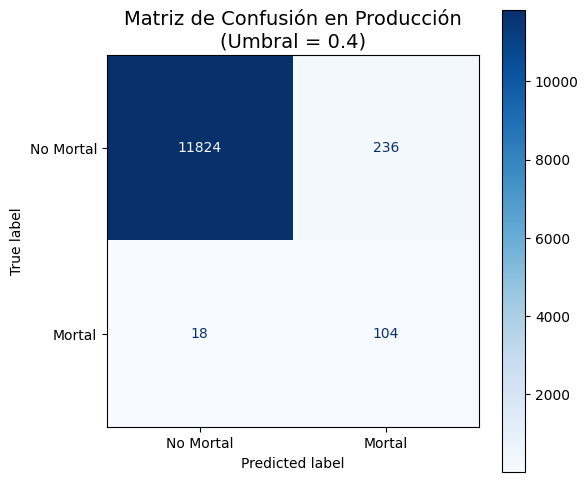

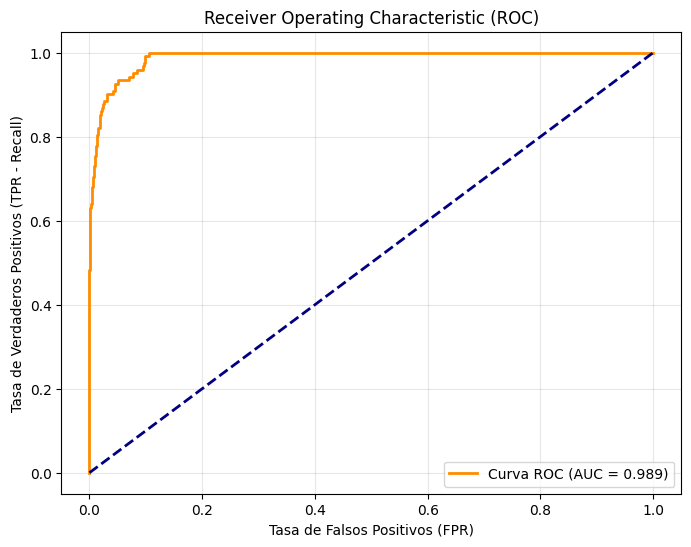

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Asumiendo que ya elegiste tu umbral táctico (ej. 0.45)
UMBRAL_FINAL = 0.40

# Predicciones con el umbral final
y_pred_final = (probs_mortal >= UMBRAL_FINAL).astype(int)

# 1. Matriz de Confusión Visual (Estilo Seaborn/Matplotlib como pide el PDF)
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Mortal', 'Mortal'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title(f'Matriz de Confusión en Producción\n(Umbral = {UMBRAL_FINAL})', fontsize=14)
plt.show()

# 2. Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, probs_mortal)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR - Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt

logger.info("Empaquetando el artefacto definitivo para Producción...")

# 1. Definimos el Campeón y el Umbral Táctico
# IMPORTANTE: Asigna aquí tu modelo ganador (ej. mejor_lgb, mejor_pipeline, etc.)
modelo_produccion = mejor_lgb # <-- Reemplazar por tu variable real
UMBRAL_FINAL = 0.33 # <-- El umbral elegido

# 2. Mostramos un resumen final por consola
logger.info("=== RESUMEN DE LA ARQUITECTURA FINAL ===")
logger.info("Modelo: Clasificador Binario (Optimizado con Undersampling 0.033 y Class Weights)")
logger.info(f"Umbral de Alarma Mortal: {UMBRAL_FINAL}")
logger.info(f"Variables Predictivas ({len(X.columns)}): {X.columns.tolist()}")

# 3. Armamos la cápsula (El Artefacto)
artefacto_produccion = {
    'modelo_predictivo': modelo_produccion, # Nombre genérico para la API
    'label_encoders': label_encoders,
    'umbral_mortal': UMBRAL_FINAL,
    'columnas_entrenamiento': X.columns.tolist()
}

# 4. Guardamos en el disco
BASE_DIR = Path.cwd().parent
models_dir = BASE_DIR / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

ruta_salida = models_dir / 'motor_mother_produccion.pkl'

try:
    joblib.dump(artefacto_produccion, RUTA_MODELO_SALIDA)
    print("\n" + "="*60)
    print(f"✅ ¡ÉXITO TOTAL! Artefacto binario exportado a: {RUTA_MODELO_SALIDA}")
    print("="*60)
    print("El Cuaderno 3 ha finalizado. El motor analítico MOTHER está listo.")
except Exception as e:
    logger.error(f"Error crítico al guardar el modelo: {e}")

2026-06-04 19:33:30,459 - INFO - Empaquetando el artefacto definitivo para Producción...
2026-06-04 19:33:30,459 - INFO - === RESUMEN DE LA ARQUITECTURA FINAL ===
2026-06-04 19:33:30,460 - INFO - Modelo: Clasificador Binario (Optimizado con Undersampling 0.033 y Class Weights)
2026-06-04 19:33:30,462 - INFO - Umbral de Alarma Mortal: 0.33
2026-06-04 19:33:30,462 - INFO - Variables Predictivas (12): ['rol_victima', 'modo_desplazamiento_victima', 'sexo_victima', 'edad_victima', 'franja_horaria', 'tipo_de_via_siniestro', 'comuna_siniestro', 'contraparte_siniestro', 'participantes_siniestro', 'anio_siniestro', 'mes_siniestro', 'dia_siniestro']



✅ ¡ÉXITO TOTAL! Artefacto binario exportado a: ../models/motor_mother_produccion.pkl
El Cuaderno 3 ha finalizado. El motor analítico MOTHER está listo.
